##### Student Declaration
##### I [Didem Demirci and 48670871] declare that this is my own work and that
##### I have not used any code or logic from other people or from sources outside of the unit.
##### I understand that it is ok to look at BUSA8000 videos and BUSA8000 resources and that researching how certain python operators / functions work is ok.

### *SECTION 1 : Exploratory Data Analysis*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

#Loading Dataset
file_path= 'koalas_dataset.xlsx'
koalas_df= pd.read_excel(file_path)

In [2]:
koalas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   koala_id             104 non-null    int64  
 1   region               104 non-null    int64  
 2   habitat              104 non-null    object 
 3   gender               104 non-null    object 
 4   age_in_years         102 non-null    float64
 5   Paw Size             104 non-null    float64
 6   total_length         104 non-null    float64
 7   head_length          104 non-null    float64
 8   ear_size             104 non-null    float64
 9   foot_length          102 non-null    float64
 10  skull_width          103 non-null    float64
 11  eye_diameter         104 non-null    float64
 12  chest_circumference  104 non-null    float64
 13  belly_circumference  103 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [3]:
koalas_df.head()

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
2,3,1,VIC,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1,VIC,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0


In [4]:
koalas_df.describe()

,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,102.000000,103.000000,104.000000,104.000000,103.000000
mean,52.500000,3.625000,3.833333,17.009615,75.088462,18.554808,22.650000,18.461765,12.917476,5.886538,62.000000,57.582524
std,30.166206,2.349086,1.909244,1.959518,4.310549,9.761017,87.562416,4.416935,11.160491,39.082636,2.045597,2.775150
min,1.000000,1.000000,1.000000,12.000000,63.000000,7.500000,5.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,26.750000,1.000000,2.250000,15.875000,72.000000,15.700000,9.875000,14.550000,9.950000,1.400000,60.500000,56.000000
50%,52.500000,3.000000,3.000000,17.000000,76.000000,17.850000,11.900000,17.950000,11.300000,1.900000,62.000000,57.500000
75%,78.250000,6.000000,5.000000,18.000000,78.000000,19.800000,17.025000,22.500000,13.100000,2.725000,63.000000,59.250000
max,104.000000,7.000000,9.000000,23.000000,84.500000,110.500000,900.800000,27.900000,120.600000,400.500000,67.000000,65.000000


In [5]:
koalas_df.shape

(104, 14)

#### *Missing Values*

In [7]:
#Checking for missing values
#Shows columnswith missig values
missing_values = koalas_df.isnull().sum()
missing_values = missing_values[missing_values >0]
print(missing_values)

age_in_years           2
foot_length            2
skull_width            1
belly_circumference    1
dtype: int64


In [8]:
#Filling missing data by gender, region and habitat
koalas_df['age_in_years'] = koalas_df.groupby(['gender', 'region', 'habitat'], observed=True)['age_in_years'].transform(lambda x: x.fillna(x.median()))
koalas_df['foot_length'] = koalas_df.groupby(['gender', 'region', 'habitat'], observed=True)['foot_length'].transform(lambda x: x.fillna(x.median()))
koalas_df['skull_width'] = koalas_df.groupby(['gender', 'region', 'habitat'], observed=True)['skull_width'].transform(lambda x: x.fillna(x.median()))
koalas_df['belly_circumference'] = koalas_df.groupby(['gender', 'region', 'habitat'], observed=True)['belly_circumference'].transform(lambda x: x.fillna(x.median()))

print(koalas_df.isnull().sum())

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           0
Paw Size               0
total_length           0
head_length            0
ear_size               0
foot_length            0
skull_width            0
eye_diameter           0
chest_circumference    0
belly_circumference    0
dtype: int64


In [9]:
#Checking Unique Values 
koalas_df.nunique()

koala_id               104
region                   7
habitat                  8
gender                   4
age_in_years            10
Paw Size                19
total_length            34
head_length             71
ear_size                71
foot_length             74
skull_width             64
eye_diameter            33
chest_circumference     19
belly_circumference     24
dtype: int64

In [10]:
#Checking Data Types
print(koalas_df.dtypes)

koala_id                 int64
region                   int64
habitat                 object
gender                  object
age_in_years           float64
Paw Size               float64
total_length           float64
head_length            float64
ear_size               float64
foot_length            float64
skull_width            float64
eye_diameter           float64
chest_circumference    float64
belly_circumference    float64
dtype: object


In [11]:
koalas_df['habitat'].unique()

array(['VIC', 'VICtoria', 'Vic', 'QLD', 'Queensland', 'Queenstown', 'qld',
       'q'], dtype=object)

In [12]:
koalas_df['gender'].unique()

array(['m', 'f', 'female', 'male'], dtype=object)

In [13]:
#Correcting erroneous and duplicate values
koalas_df['gender'] = koalas_df['gender'].replace({'m': 'male', 'f': 'female'})
koalas_df['habitat'] = koalas_df['habitat'].replace({'Queensland': 'QLD', 'VICtoria': 'VIC', 'Queenstown': 'QLD', 'q': 'QLD', 'qld': 'QLD', 'Vic': 'VIC'})

In [14]:
print(koalas_df['gender'].unique())

['male' 'female']


In [15]:
print(koalas_df['habitat'].unique())

['VIC' 'QLD']


In [16]:
#Converting 'habitat','gender' and 'region'columns to categorical data type
koalas_df['habitat']=koalas_df['habitat'].astype('category')
koalas_df['gender']=koalas_df['gender'].astype('category')
koalas_df['region']=koalas_df['region'].astype('category')

In [17]:
print(koalas_df.dtypes)

koala_id                  int64
region                 category
habitat                category
gender                 category
age_in_years            float64
Paw Size                float64
total_length            float64
head_length             float64
ear_size                float64
foot_length             float64
skull_width             float64
eye_diameter            float64
chest_circumference     float64
belly_circumference     float64
dtype: object


#### *Outliers*

In [19]:
#select only numeric columns
numeric_columns = koalas_df.select_dtypes(include=['float64', 'int64'])
#Checking Outliers
Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)
IQR = Q3 - Q1

#Identify rows with outliers
outliers = ((numeric_columns < (Q1 - 1.5*IQR)) | (numeric_columns  > (Q3 +1.5 * IQR))).sum()
print("Number of Outliers in each column:")
print(outliers)

Number of Outliers in each column:
koala_id               0
age_in_years           2
Paw Size               4
total_length           0
head_length            4
ear_size               2
foot_length            0
skull_width            9
eye_diameter           2
chest_circumference    1
belly_circumference    3
dtype: int64


In [20]:
#Filtering - Clean Outliers
filtered_koalas_df = koalas_df[~((numeric_columns < (Q1 - 1.5 * IQR)) | (numeric_columns > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Cleaned dataset size: {filtered_koalas_df.shape}")

Cleaned dataset size: (83, 14)


In [21]:
#Checking fot duplicate rows
duplicates= koalas_df.duplicated().sum()
print(f"Number o repeating rows: {duplicates}")

Number o repeating rows: 0


### *SECTION 2 : Data visualisation*

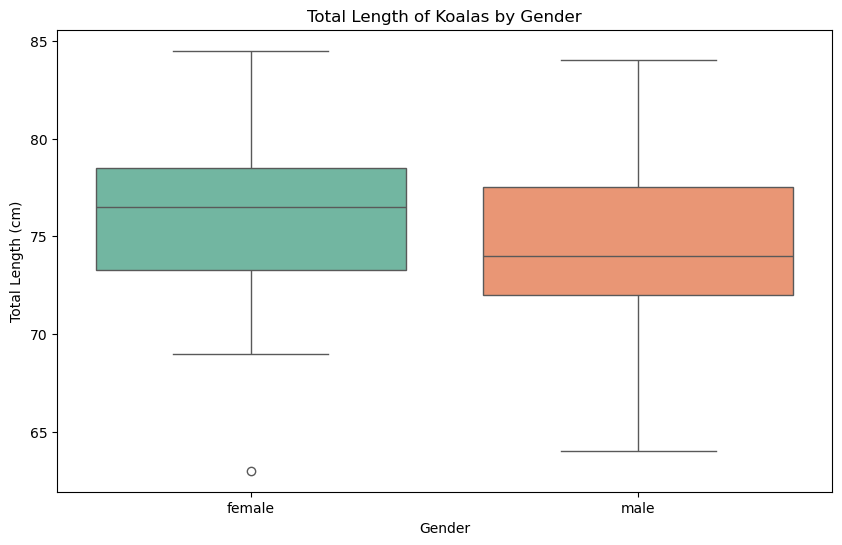

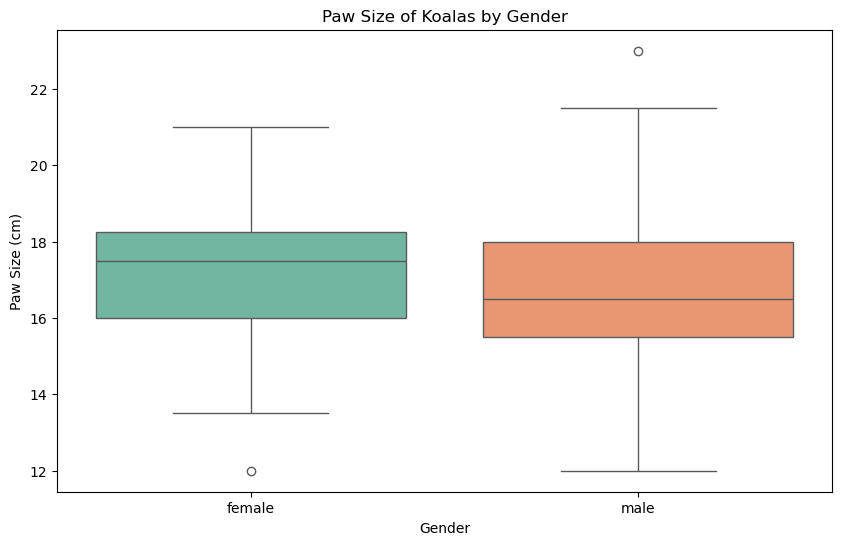

In [23]:
#Boxplot to visualise total length of koalas grouped by gender
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='total_length', data=koalas_df,hue='gender', palette='Set2')
plt.title('Total Length of Koalas by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Length (cm)')
plt.savefig('koala_total_length_by_gender.png')
plt.show()

#Boxplot to visualise Paw Size of koalas grouped by gender
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='Paw Size', data=koalas_df,hue='gender', palette='Set2')
plt.title('Paw Size of Koalas by Gender')
plt.xlabel('Gender')
plt.ylabel('Paw Size (cm)')
plt.savefig('koala_paw_size_by_gender.png') 
plt.show()

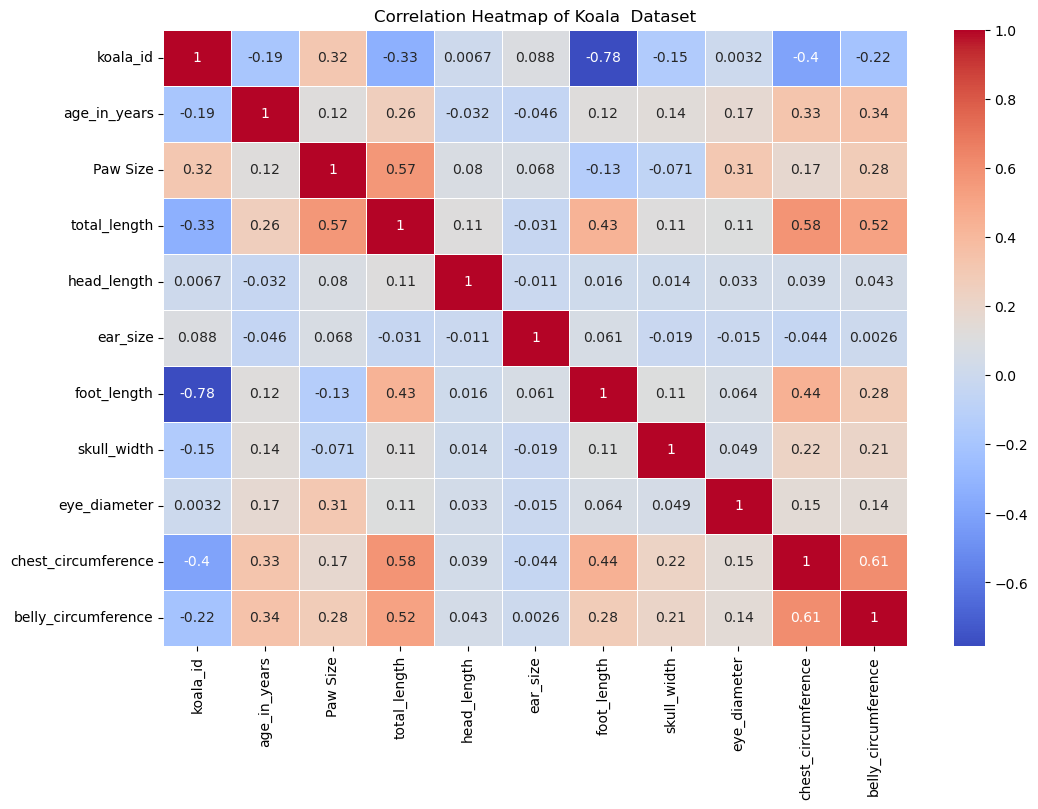

In [24]:
#Correlation Heatmap
numeric_columns = koalas_df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))
corr_matrix = numeric_columns.corr()
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Koala  Dataset')
plt.savefig('correlation_heatmap_koala_dataset.png')
plt.show()

### *SECTION 3: Analysis*

##### •Is the mean head length of the Koalas significantly different from 92.0 mm?

In [27]:
#This question can be done with one sample t-test
#testing whether koala head length is significantly different from 92.0 mm
head_lengths = koalas_df['head_length']
#One sample t-test against 92.0 mm
t_stat, p_value = stats.ttest_1samp(head_lengths, 92.0)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

#Evaluating the hypothesis with p value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The mean head length is significantly different from 92.0 mm.")
else:
    print("Fail to reject the null hypothesis: The mean head length is ot significantly different from 92.0 mm.")

T-statistic: -76.7334940014102
P-value: 1.0422076043627138e-92
Reject the null hypothesis: The mean head length is significantly different from 92.0 mm.


##### •Do male and female Koalas have significantly different mean head lengths?

In [29]:
#This question can be done with independent t-test
#Seperate head length of male and female koalas
male_koalas = koalas_df[koalas_df['gender'] == 'm']['head_length']
female_koalas = koalas_df[koalas_df['gender'] == 'f']['head_length']
t_stat, p_value = stats.ttest_ind(male_koalas, female_koalas)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

#Evaluating the hypothesis with p value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant in head lengths between male and female koalas.")
else:
    print("Fail to reject the null hypothesis: There is significant difference in head lengths between male and female koalas.")

T-statistic: nan
P-value: nan
Fail to reject the null hypothesis: There is significant difference in head lengths between male and female koalas.


##### •Can we predict the total length of a Koala based on its head length?

In [31]:
#This question can be done with simple linear regression.
X = koalas_df[['head_length']]
y= koalas_df['total_length']

#Creating Model
model= LinearRegression()
model.fit(X,y)

#Print the intercept and coefficient
print(f"Intercept (β0): {model.intercept_}")
print(f"Coefficient (β1): {model.coef_[0]}")

# R-squared value
r_squared = model.score(X, y)
print(f"R-squared: {r_squared}")

#Predict total length based on head length
head_length_value = 100
predicted_total_length = model.predict(pd.DataFrame([[head_length_value]], columns=['head_length']))
print(f"Predicted total length for a koala with head length {head_length_value} mm: {predicted_total_length[0]} cm")

Intercept (β0): 74.15505485056627
Coefficient (β1): 0.05030538194595326
R-squared: 0.01297638663715961
Predicted total length for a koala with head length 100 mm: 79.1855930451616 cm


##### •Can we predict the total length of a Koala based on multiple factors such as head length, skull width, and foot length?

In [33]:
#This question can be done with multiple linear regression.
X = koalas_df[['head_length', 'skull_width', 'foot_length']]
y = koalas_df['total_length']

#Creating Model
model= LinearRegression()
model.fit(X, y)

print(f"Intercept (β0): {model.intercept_}")
print(f"Coefficient (β1, β2, β3 ): {model.coef_}")

# R-squared value
r_squared = model.score(X, y)
print(f"R-squared: {r_squared}")

#Prediction
head_length_value = 100
skull_width_value = 70
foot_length_value = 25

input_data = pd.DataFrame([[head_length_value,skull_width_value, foot_length_value]],
                          columns=['head_length', 'skull_width', 'foot_length'])

#Predict total length for these spesific values
predicted_total_length = model.predict(input_data)
print(f"Predicted total length for a koala with head length {head_length_value} mm, skull width {skull_width_value} mm, and foot length {foot_length_value} cm : {predicted_total_length[0]} cm")

Intercept (β0): 66.25041094063538
Coefficient (β1, β2, β3 ): [0.04687328 0.02647493 0.41346424]
R-squared: 0.20199995427333206
Predicted total length for a koala with head length 100 mm, skull width 70 mm, and foot length 25 cm : 83.1275891889961 cm


##### •Do environmental factors such as state affect Koala’s physical characteristics?

In [35]:
#This question can be done with Analysis of Varience.
koalas_by_region = [koalas_df[koalas_df['region'] == region]['total_length'] for region in koalas_df['region'].unique()]
#One way Anova Test
f_stat, p_value = stats.f_oneway(*koalas_by_region)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

#Evaluating the hypothesis with p-value
alpha=0.05
if p_value < alpha:
    print("Reject the null hypothesis: Environmental factors (region) significantly affect koala's total length.")
else:
    print("Fail to reject the null hypothesis: Environmental factors (region) do not significantly affect koala's total length.")

F-statistic: 14.581727773273526
P-value: 8.452488795567205e-12
Reject the null hypothesis: Environmental factors (region) significantly affect koala's total length.


##### •What factors are correlated with the total length of a Koala?

In [37]:
#This question can be done with correlation analysis.
numeric_df = koalas_df.select_dtypes(include=['float64', 'int64'])

#Creating the correlation matrix
correlation_matrix = numeric_df.corr()

print(correlation_matrix['total_length'])

koala_id              -0.334329
age_in_years           0.256524
Paw Size               0.565646
total_length           1.000000
head_length            0.113914
ear_size              -0.030654
foot_length            0.431233
skull_width            0.114023
eye_diameter           0.106518
chest_circumference    0.577890
belly_circumference    0.515591
Name: total_length, dtype: float64


### *SECTION 4: Recommendations*

Findings on the relationship between the physical features of the koalas and the surrounding parameters emphasize the protection of the habitats that the koalas are living in. For instance, regional parameters determine the total length of the koalas; hence, habitat diversity represents an important function in the healthy look of the koalas. Besides, the high value of correlation between such physical parameters as chest circumference, paw size, and abdominal circumference and the overall length of koalas testifies that these parameters can be followed as an indicator of health and growth. Thus, for the healthy development and protection of koalas, special protection and monitoring of places they inhabit are in particular needed. It suggests that this strategy would avoid the destruction of koala habitats and enhance their existing ones.